# Ettin classifier (jhu-clsp/ettin-encoder-400m)

The SOTA encoder - [Ettin Suite: SoTA Paired Encoders and Decoders](https://huggingface.co/blog/ettin)

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import json

from google.colab import drive, userdata

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch
from datasets import Dataset

### Set up Google Drive mounting and define input/output paths:

In [2]:
# Mount the google drive folder
drive.mount('/content/drive', force_remount = True) # force reconnection

# Define directory, input, and output paths
project_directory = "/content/drive/MyDrive/Colab Notebooks/DS266/final_project"

# Input file with all original-rewrite pairs
final_file = os.path.join(project_directory, "data/final_no_leak_v2.parquet")

# # Output file
# output_file = os.path.join(project_directory, "data/out.parquet")

# Ensure the output directory exists
if not os.path.exists(project_directory):
  os.makedirs(project_directory)

Mounted at /content/drive


### Read the input file:

In [3]:
# Read input file with the sampled original-rewrite pairs
final_df = pd.read_parquet(final_file)
print('Sucessfully read the input file with the sampled original-rewrite pairs!')

print(f'The input file contains {len(final_df)} records/rows.')
print(f'Column names: {list(final_df.columns)}')

print('\nThe first 3 rows:')
display(final_df.head(3))

Sucessfully read the input file with the sampled original-rewrite pairs!
The input file contains 5306 records/rows.
Column names: ['question', 'original', 'rewritten_text', 'original_author', 'rewriter']

The first 3 rows:


,question,original,rewritten_text,original_author,rewriter
51073,"$10,000 to invest in the house - Pay down prin...",There is no guarantee improvements will raise ...,"Upgrades rarely increase appraised value, and ...",human,kimi
93542,$65000/year or $2500 every two weeks: If I cla...,# Take-Home Pay Calculation\n\nI need to clari...,Take-Home Pay Calculation\n\nYour two figures ...,claude,gpt
9429,"(Almost) no credit unions in New York City, why?",Short answer: there are fewer credit unions in...,# Why New York City Has Fewer Credit Unions\n\...,gpt,claude


In [4]:
# rename columns
final_df.rename(columns = {'original': 'original_text',
                           'rewriter': 'rewrite_author'},
                inplace = True)

In [5]:
print(f'New column names: {list(final_df.columns)}')

New column names: ['question', 'original_text', 'rewritten_text', 'original_author', 'rewrite_author']


### Data Exploration & cleaning

In [6]:
print(final_df['original_author'].value_counts(), end = '\n\n')
print(final_df['rewrite_author'].value_counts())

original_author
gpt       1062
human     1061
claude    1061
kimi      1061
gemini    1061
Name: count, dtype: int64

rewrite_author
gemini    1361
claude    1336
kimi      1328
gpt       1281
Name: count, dtype: int64


In [7]:
print(final_df.isna().sum(), end = '\n\n')

# na_df -- the dataframe that contains nan responses (rewrites)
na_df = final_df[final_df['rewritten_text'].isna()]

print(na_df['rewrite_author'].value_counts())
display(na_df.head(3))

question           0
original_text      0
rewritten_text     0
original_author    0
rewrite_author     0
dtype: int64

Series([], Name: count, dtype: int64)


,question,original_text,rewritten_text,original_author,rewrite_author


Create the binary `labels` column (human `1` vs. machine `0`)

In [8]:
# # drop nan and duplicates
# cleaned_df = final_df.dropna(subset = ['rewritten_text']).drop_duplicates().reset_index(drop = True)

# print(cleaned_df.isna().sum(), end = '\n\n')
# print(cleaned_df['labels'].value_counts(), end = '\n\n')
# display(cleaned_df.head(3))

# Create the 'labels' column
final_df['labels'] = (final_df['original_author'] == 'human').astype(int)

In [9]:
# stratification

df_human = final_df[final_df['original_author'] == 'human']
df_gemini = final_df[final_df['original_author'] == 'gemini']
df_gpt = final_df[final_df['original_author'] == 'gpt']
df_claude = final_df[final_df['original_author'] == 'claude']
df_kimi = final_df[final_df['original_author'] == 'kimi']

                                        # number of human responses = 4 * individual llm responses
df_human_sampled = df_human.sample(n = int(len(df_human)/4)*4, random_state = 42)
df_gemini_sampled = df_gemini.sample(n = int(len(df_human)/4), random_state = 42)
df_gpt_sampled = df_gpt.sample(n = int(len(df_human)/4), random_state = 42)
df_claude_sampled = df_claude.sample(n = int(len(df_human)/4), random_state = 42)
df_kimi_sampled = df_kimi.sample(n = int(len(df_human)/4), random_state = 42)

stratified_df = pd.concat([df_human_sampled, df_gemini_sampled, df_gpt_sampled, df_claude_sampled, df_kimi_sampled]).reset_index(drop = True)
print(stratified_df['original_author'].value_counts(), end = '\n\n')
print(stratified_df['labels'].value_counts(), end = '\n\n')
display(stratified_df.head(3))

original_author
human     1060
gemini     265
gpt        265
claude     265
kimi       265
Name: count, dtype: int64

labels
1    1060
0    1060
Name: count, dtype: int64



,question,original_text,rewritten_text,original_author,rewrite_author,labels
0,Asset classes: Is a Guaranteed Investment Cert...,"Instead of ""stocks"" I would refer to that asse...","I would use ""equity"" instead of ""stocks"" and ""...",human,gemini,1
1,"Please explain what is ""Fifth generation compu...",The Fifth Generation Computer Systems (FGCS) ...,The Fifth Generation Computer Systems (FGCS) w...,human,gemini,1
2,S&P reports: number of shareholders?,Yes these are the number of shareholders that ...,This statistic is largely meaningless as it pr...,human,gemini,1


In [10]:
# Shuffle the data
shuffled_indices = np.random.permutation(len(stratified_df))
shuffled_df = stratified_df.iloc[shuffled_indices].reset_index(drop = True)
display(shuffled_df.head(3))

,question,original_text,rewritten_text,original_author,rewrite_author,labels
0,Canadian accepting money electronically from A...,I am not aware of a version of Interac availab...,I’m not aware of an Interac option available i...,human,gpt,1
1,How decreasing the prime interest rate helps t...,# How Lower Prime Rates Offset Falling Oil Pri...,How Lower Prime Rates Offset Falling Oil Price...,claude,gpt,0
2,what kind of earthquake was haiti,The 2010 Haiti earthquake was a catastrophic m...,A catastrophic magnitude-7.0 Mw earthquake str...,human,kimi,1


In [11]:
# train-test split

train_df, test_df = train_test_split(shuffled_df, test_size = 0.2, stratify = shuffled_df['labels'], random_state = 42)
print(f'Total samples: {len(shuffled_df)}')
print(f'Training samples: {len(train_df)}')
print(f'Testing samples: {len(test_df)}')

Total samples: 2120
Training samples: 1696
Testing samples: 424


In [12]:
# Check if there's class imbalance
print(f'Label value counts on the training dataset:\n{train_df['labels'].value_counts()}')
print(f'Label value counts on the testing dataset:\n{test_df['labels'].value_counts()}')

Label value counts on the training dataset:
labels
0    848
1    848
Name: count, dtype: int64
Label value counts on the testing dataset:
labels
1    212
0    212
Name: count, dtype: int64


In [13]:
# Convert the training and testing dataset to Dataset format

train_data = Dataset.from_pandas(train_df[['original_text', 'rewritten_text', 'labels']])
test_data = Dataset.from_pandas(test_df[['original_text', 'rewritten_text', 'labels']])

### Ettin classifier development

Define tokenizer

In [14]:
ettin_checkpoint = 'jhu-clsp/ettin-encoder-400m'
ettin_tokenizer = AutoTokenizer.from_pretrained(ettin_checkpoint)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

Define the training and testing inputs

In [15]:
def tokenization(df):
  return ettin_tokenizer(df['original_text'],
                         df['rewritten_text'],
                         padding = 'max_length',
                         truncation = True,
                         max_length = 512)

train_tokenized = train_data.map(tokenization, batched = True)
train_tokenized.set_format('torch')

test_tokenized = test_data.map(tokenization, batched = True)
test_tokenized.set_format('torch')

Map:   0%|          | 0/1696 [00:00<?, ? examples/s]

Map:   0%|          | 0/424 [00:00<?, ? examples/s]

Define metrics

In [16]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis = -1)

    return {'accuracy': accuracy_score(labels, predictions),
            'f1_score': f1_score(labels, predictions, average = 'binary')}

### Baseline model (untrained Ettin)

In [17]:
ettin_baseline_model = AutoModelForSequenceClassification.from_pretrained(ettin_checkpoint, num_labels = 2) # binary classification

baseline_training_args = TrainingArguments(output_dir = './ettin_baseline',
                                           per_device_eval_batch_size = 8)

baseline_trainer = Trainer(model = ettin_baseline_model,
                           args = baseline_training_args,
                           eval_dataset = test_tokenized,
                           compute_metrics = compute_metrics)

pytorch_model.bin:   0%|          | 0.00/1.58G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/172 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: jhu-clsp/ettin-encoder-400m
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
decoder.weight    | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [18]:
baseline_results = baseline_trainer.evaluate()

model.safetensors:   0%|          | 0.00/1.58G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:321: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


In [19]:
print(f"(Baseline) Accuracy: {baseline_results['eval_accuracy']} | F1: {baseline_results['eval_f1_score']}")

(Baseline) Accuracy: 0.5117924528301887 | F1: 0.5035971223021583


### Fine-tuned model (trained)

In [20]:
ettin_finetuned_model = AutoModelForSequenceClassification.from_pretrained(ettin_checkpoint, num_labels = 2) # binary classification

finetune_training_args = TrainingArguments(output_dir = './ettin_finetuned',
                                           num_train_epochs = 3,              # likely to converge already
                                           learning_rate = 0.00002,
                                           per_device_train_batch_size = 8,   # to prevent overfitting
                                           per_device_eval_batch_size = 8,    # to prevent overfitting
                                           eval_strategy = 'epoch',
                                           save_strategy = 'epoch',
                                           weight_decay = 0.01,               # prevent overfitting to specific punctuation habits
                                           load_best_model_at_end = True,
                                           metric_for_best_model = 'f1_score',
                                           logging_steps = 100,
                                           warmup_steps = 500)                # stablize gradients

finetune_trainer = Trainer(model = ettin_finetuned_model,
                           args = finetune_training_args,
                           train_dataset = train_tokenized,
                           eval_dataset = test_tokenized,
                           compute_metrics = compute_metrics)

finetune_trainer.train()

Loading weights:   0%|          | 0/172 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: jhu-clsp/ettin-encoder-400m
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
decoder.weight    | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Score
1,0.127486,0.015977,0.992925,0.992974
2,0.030154,0.036100,0.988208,0.988290
3,0.004701,0.009945,0.997642,0.997636


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=636, training_loss=0.16249770592347537, metrics={'train_runtime': 453.6982, 'train_samples_per_second': 11.215, 'train_steps_per_second': 1.402, 'total_flos': 5380844984008704.0, 'train_loss': 0.16249770592347537, 'epoch': 3.0})

In [21]:
finetuned_results = finetune_trainer.evaluate()

In [22]:
print(f"(Baseline) Accuracy: {baseline_results['eval_accuracy']} | F1: {baseline_results['eval_f1_score']}")
print(f"(Finetuned) Accuracy: {finetuned_results['eval_accuracy']} | F1: {finetuned_results['eval_f1_score']}")

(Baseline) Accuracy: 0.5117924528301887 | F1: 0.5035971223021583
(Finetuned) Accuracy: 0.9976415094339622 | F1: 0.9976359338061466


### Visualization

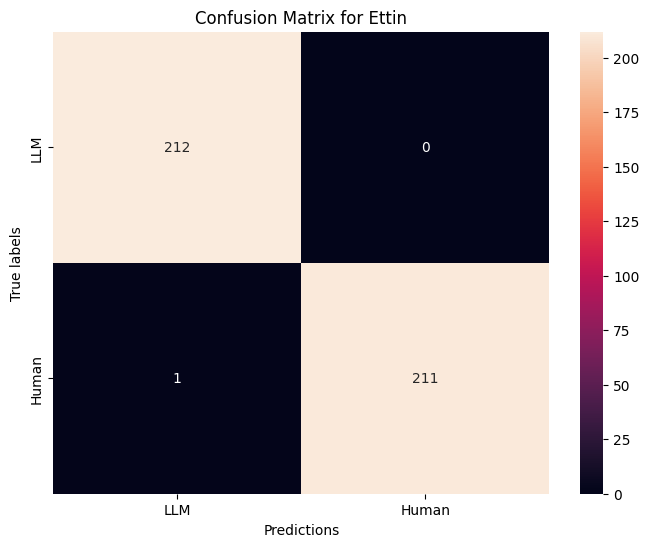


Classification Report:
              precision    recall  f1-score   support

         LLM       1.00      1.00      1.00       212
       Human       1.00      1.00      1.00       212

    accuracy                           1.00       424
   macro avg       1.00      1.00      1.00       424
weighted avg       1.00      1.00      1.00       424



In [23]:
predictions = finetune_trainer.predict(test_tokenized)
pred = np.argmax(predictions.predictions, axis = -1)
labels = test_df['labels'].values

cm = confusion_matrix(labels, pred)
plt.figure(figsize = (8,6))
sns.heatmap(cm,
            annot = True,
            fmt = 'd', # format the annotation from scientific to decimals
            xticklabels = ['LLM', 'Human'],
            yticklabels = ['LLM', 'Human'])
plt.xlabel('Predictions')
plt.ylabel('True labels')
plt.title('Confusion Matrix for Ettin')
plt.show()

print("\nClassification Report:")
print(classification_report(labels, pred, target_names = ['LLM', 'Human']))

### Save the final dataframe to parquet

In [24]:
finetune_trainer.save_model("./finetuned_ettin")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]